# HopeEXP - Task C: Extraccion de Fragmentos
**Modelo:** `microsoft/mdeberta-v3-base`  
**Tipo de tarea:** Token classification con etiquetas BIO (`O`, `B-SPAN`, `I-SPAN`)  
**Objetivo:** extraer hasta 3 spans exactos que describan el resultado esperado o evitado

## 0. Setup e Imports

In [1]:
# Instalar dependencias si es necesario
!pip install transformers torch scikit-learn pandas numpy matplotlib seaborn sentencepiece protobuf

In [2]:
import os
import sys
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split as sk_split
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup

sys.path.insert(0, os.path.abspath('.'))

from src.span_model import build_span_model, build_span_tokenizer, load_span_model, save_span_model
from src.span_utils import (
    aggregate_predictions,
    build_dataloader,
    build_source_text,
    collect_logits,
    compute_class_weights,
    evaluate_span_predictions,
    format_metrics,
    limit_records,
    load_primary_labels,
    load_records,
    predictions_to_submission,
    save_json,
    set_seed,
    summarize_dataset,
)

print('Imports correctos')

/Users/adrian/Documents/Universidad/PLN/Practica-PLN/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Imports correctos


In [3]:
SEED = 42
set_seed(SEED)

if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
    print(f'Dispositivo: CUDA ({torch.cuda.get_device_name(0)})')
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
    print('Dispositivo: Apple Silicon (MPS)')
else:
    DEVICE = torch.device('cpu')
    print('Dispositivo: CPU')

Dispositivo: Apple Silicon (MPS)


## 1. Configuracion de Hiperparametros

In [4]:
TRAIN_PATH = './HopeEXP_Train.jsonl'
TEST_PATH = './HopeEXP_Test_unlabeled.jsonl'
DEV_SIZE = 0.20

MODEL_NAME = 'microsoft/mdeberta-v3-base'
MAX_LENGTH = 256
STRIDE = 64
BATCH_SIZE = 8
NUM_EPOCHS = 4
LR = 2e-5
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.1
GRAD_CLIP = 1.0

MAX_TRAIN_EXAMPLES = None 
MAX_DEV_EXAMPLES = None
MAX_TEST_EXAMPLES = None

OUTPUT_DIR = './outputs/task_c_spans_notebook'
BEST_MODEL_DIR = os.path.join(OUTPUT_DIR, 'best_model')
SUBMISSION_NAME = 'submission_task_c_notebook.json'
PRIMARY_LABELS_PATH = None  # Opcional: predicciones de Task A para forzar vacio en Not Hope/Hopelessness

os.makedirs(OUTPUT_DIR, exist_ok=True)
print('Configuracion lista')

Configuracion lista


## 2. Carga y Preparacion de Datos

In [5]:
full_train_records = load_records(TRAIN_PATH)
test_records = load_records(TEST_PATH)

train_records, dev_records = sk_split(
    full_train_records,
    test_size=DEV_SIZE,
    random_state=SEED,
    stratify=[record.get('primary_label', '') for record in full_train_records],
)

train_records = limit_records(train_records, MAX_TRAIN_EXAMPLES)
dev_records = limit_records(dev_records, MAX_DEV_EXAMPLES)
test_records = limit_records(test_records, MAX_TEST_EXAMPLES)

def records_to_df(records):
    rows = []
    for record in records:
        spans = record.get('span_annotations', []) or []
        rows.append({
            'row_id': record.get('row_id'),
            'lang': record.get('lang'),
            'primary_label': record.get('primary_label'),
            'title': record.get('title'),
            'selftext': record.get('selftext'),
            'source_text': build_source_text(record),
            'span_count': len(spans),
            'span_texts': ' ||| '.join(span.get('span', '') for span in spans),
        })
    df = pd.DataFrame(rows)
    if not df.empty:
        df['char_length'] = df['source_text'].str.len()
        df['is_hopeful'] = df['primary_label'].isin(['General Hope', 'Realistic Hope', 'Unrealistic Hope', 'Sarcastic Hope'])
    return df

train_df = records_to_df(train_records)
dev_df = records_to_df(dev_records)
test_df = records_to_df(test_records)

print(f'Train completo: {len(full_train_records)} muestras')
print(f'  -> Train: {len(train_records)} | Dev: {len(dev_records)} (split {int((1-DEV_SIZE)*100)}/{int(DEV_SIZE*100)})')
print(f'  -> Test: {len(test_records)} muestras')
print()
print('Resumen train:', summarize_dataset(train_records))
print('Resumen dev:', summarize_dataset(dev_records))
display(train_df.head(3))

Train completo: 4857 muestras
  -> Train: 3885 | Dev: 972 (split 80/20)
  -> Test: 2082 muestras

Resumen train: {'total_records': 3885, 'hopeful_records': 2430, 'records_with_spans': 2429}
Resumen dev: {'total_records': 972, 'hopeful_records': 608, 'records_with_spans': 608}


,row_id,lang,primary_label,title,selftext,source_text,span_count,span_texts,char_length,is_hopeful
0,5377,EN,Sarcastic Hope,My Partner Finally Remembered My Birthday—How ...,"After three years together, my significant oth...",My Partner Finally Remembered My Birthday—How ...,1,I have so much hope that things will magically...,803,True
1,7161,EN,Not Hope,Reddittors make finding answers ridiculously t...,"Every reddit post that poses a question, the t...",Reddittors make finding answers ridiculously t...,0,,339,False
2,4124,ES,Realistic Hope,Alguien está o ha estado en una banda?,Me gustaría estar en una banda musical pero no...,Alguien está o ha estado en una banda?\nMe gus...,1,Me gustaría estar en una banda musical,125,True


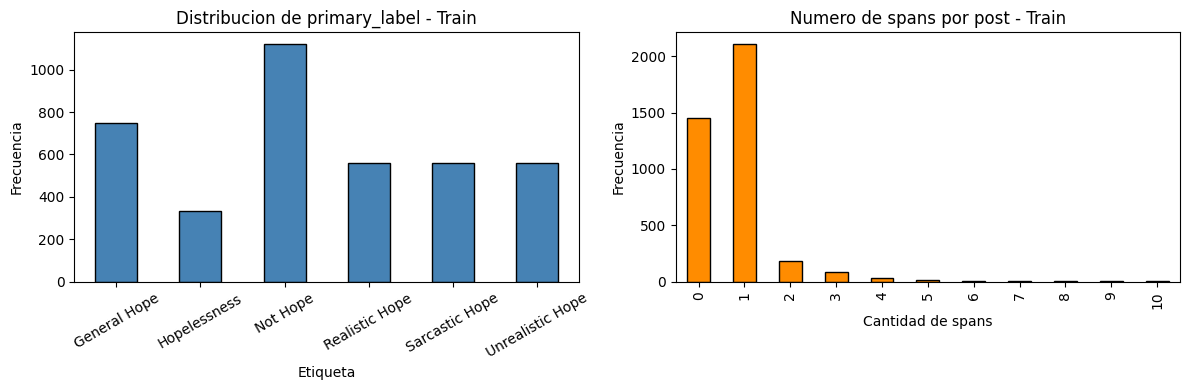

,train,dev
primary_label,,
Not Hope,1120,280
General Hope,749,188
Realistic Hope,561,140
Sarcastic Hope,560,140
Unrealistic Hope,560,140
Hopelessness,335,84


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

train_df['primary_label'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='black'
)
axes[0].set_title('Distribucion de primary_label - Train')
axes[0].set_xlabel('Etiqueta')
axes[0].set_ylabel('Frecuencia')
axes[0].tick_params(axis='x', rotation=30)

train_df['span_count'].value_counts().sort_index().plot(
    kind='bar', ax=axes[1], color='darkorange', edgecolor='black'
)
axes[1].set_title('Numero de spans por post - Train')
axes[1].set_xlabel('Cantidad de spans')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'task_c_label_distribution.png'), dpi=150)
plt.show()

display(pd.concat([
    train_df['primary_label'].value_counts().rename('train'),
    dev_df['primary_label'].value_counts().rename('dev')
], axis=1).fillna(0).astype(int))

### Comparativa de spans por tipo de post

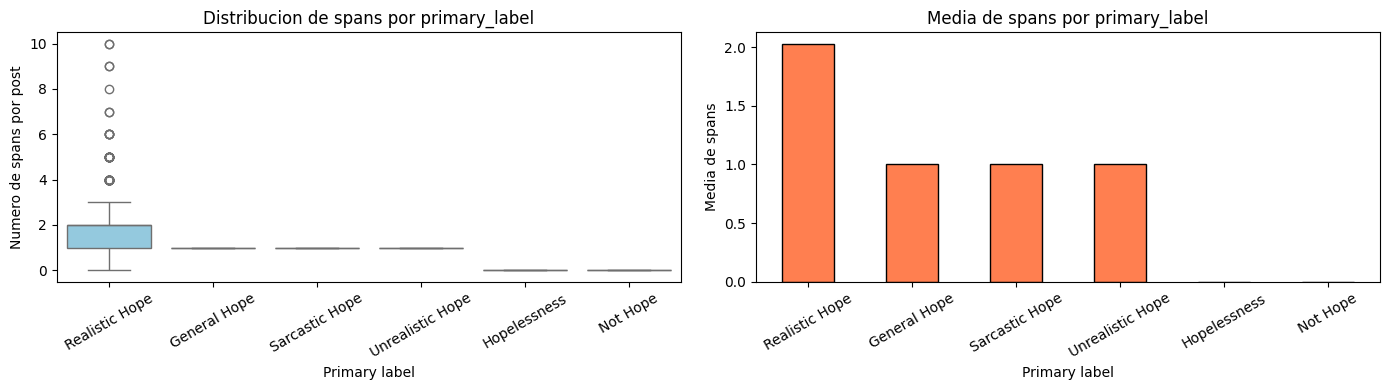

,posts,total_spans,mean_spans,median_spans,pct_with_spans
primary_label,,,,,
Realistic Hope,561,1137,2.026738,2.0,99.82
General Hope,749,749,1.000000,1.0,100.00
Sarcastic Hope,560,560,1.000000,1.0,100.00
Unrealistic Hope,560,560,1.000000,1.0,100.00
Hopelessness,335,0,0.000000,0.0,0.00
Not Hope,1120,0,0.000000,0.0,0.00


In [7]:
span_by_label = (
    train_df.groupby('primary_label')
    .agg(
        posts=('row_id', 'count'),
        total_spans=('span_count', 'sum'),
        mean_spans=('span_count', 'mean'),
        median_spans=('span_count', 'median'),
        pct_with_spans=('span_count', lambda values: (values > 0).mean()),
    )
    .sort_values('mean_spans', ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.boxplot(
    data=train_df,
    x='primary_label',
    y='span_count',
    order=span_by_label.index,
    ax=axes[0],
    color='skyblue',
)
axes[0].set_title('Distribucion de spans por primary_label')
axes[0].set_xlabel('Primary label')
axes[0].set_ylabel('Numero de spans por post')
axes[0].tick_params(axis='x', rotation=30)

span_by_label['mean_spans'].plot(
    kind='bar',
    ax=axes[1],
    color='coral',
    edgecolor='black',
)
axes[1].set_title('Media de spans por primary_label')
axes[1].set_xlabel('Primary label')
axes[1].set_ylabel('Media de spans')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'task_c_spans_by_primary_label.png'), dpi=150)
plt.show()

display(span_by_label.assign(pct_with_spans=lambda df: (100 * df['pct_with_spans']).round(2)))

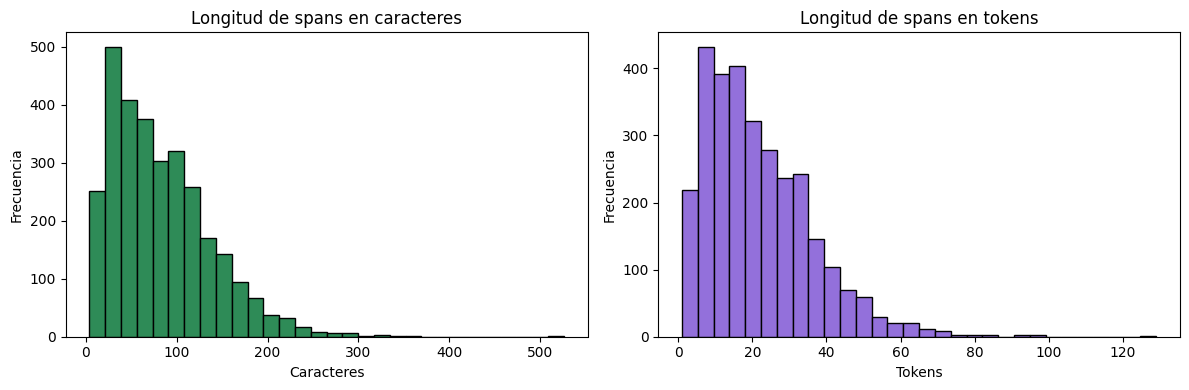

Spans anotados en train: 3006
Longitud media (chars): 83.0
Percentil 95 (chars): 183.0
Longitud media (tokens): 21.8
Percentil 95 (tokens): 49.0


In [8]:
span_lengths_chars = [
    len(span.get('span', ''))
    for record in train_records
    for span in (record.get('span_annotations') or [])
    if span.get('span')
]

tokenizer_preview = build_span_tokenizer(MODEL_NAME)
span_lengths_tokens = [
    len(tokenizer_preview.tokenize(span.get('span', '')))
    for record in train_records
    for span in (record.get('span_annotations') or [])
    if span.get('span')
]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(span_lengths_chars, bins=30, color='seagreen', edgecolor='black')
axes[0].set_title('Longitud de spans en caracteres')
axes[0].set_xlabel('Caracteres')
axes[0].set_ylabel('Frecuencia')

axes[1].hist(span_lengths_tokens, bins=30, color='mediumpurple', edgecolor='black')
axes[1].set_title('Longitud de spans en tokens')
axes[1].set_xlabel('Tokens')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'task_c_span_lengths.png'), dpi=150)
plt.show()

print(f'Spans anotados en train: {len(span_lengths_chars)}')
print(f'Longitud media (chars): {np.mean(span_lengths_chars):.1f}')
print(f'Percentil 95 (chars): {np.percentile(span_lengths_chars, 95):.1f}')
print(f'Longitud media (tokens): {np.mean(span_lengths_tokens):.1f}')
print(f'Percentil 95 (tokens): {np.percentile(span_lengths_tokens, 95):.1f}')

## 3. Tokenizador y DataLoaders

In [9]:
tokenizer = build_span_tokenizer(MODEL_NAME)
print(f'Tokenizer cargado: {MODEL_NAME}')

sample_text_lengths = [
    len(tokenizer.encode(build_source_text(record), add_special_tokens=True))
    for record in train_records[:500]
]
print(f'Longitud media tokens (muestra 500): {np.mean(sample_text_lengths):.1f}')
print(f'Percentil 95: {np.percentile(sample_text_lengths, 95):.0f}')
print(f'Maximo: {max(sample_text_lengths)}')
print(f'MAX_LENGTH configurado: {MAX_LENGTH}')
print(f'STRIDE configurado: {STRIDE}')

Tokenizer cargado: microsoft/mdeberta-v3-base
Longitud media tokens (muestra 500): 333.1
Percentil 95: 769
Maximo: 5954
MAX_LENGTH configurado: 256
STRIDE configurado: 64


In [10]:
train_dataset, train_loader = build_dataloader(
    train_records, tokenizer, max_length=MAX_LENGTH, stride=STRIDE,
    batch_size=BATCH_SIZE, shuffle=True, include_labels=True
)
dev_dataset, dev_loader = build_dataloader(
    dev_records, tokenizer, max_length=MAX_LENGTH, stride=STRIDE,
    batch_size=BATCH_SIZE, shuffle=False, include_labels=True
)
test_dataset, test_loader = build_dataloader(
    test_records, tokenizer, max_length=MAX_LENGTH, stride=STRIDE,
    batch_size=BATCH_SIZE, shuffle=False, include_labels=False
)

print(f'Features - Train: {len(train_dataset)} | Dev: {len(dev_dataset)} | Test: {len(test_dataset)}')
print(f'Batches - Train: {len(train_loader)} | Dev: {len(dev_loader)} | Test: {len(test_loader)}')

sample_batch = next(iter(train_loader))
print('\nForma de un batch:')
for key, value in sample_batch.items():
    print(f'  {key}: {tuple(value.shape)}')

Features - Train: 7609 | Dev: 1893 | Test: 3936
Batches - Train: 952 | Dev: 237 | Test: 492

Forma de un batch:
  input_ids: (8, 256)
  attention_mask: (8, 256)
  feature_id: (8,)
  labels: (8, 256)
  token_type_ids: (8, 256)


## 4. Construccion del Modelo

In [11]:
model = build_span_model(MODEL_NAME).to(DEVICE).float()
class_weights = compute_class_weights(train_dataset)

n_params = sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)
print(f'Parametros entrenables: {n_params:,}')
print('Etiquetas BIO:', model.config.id2label)
print('Pesos de clase:', class_weights.tolist())

Loading weights: 100%|██████████| 198/198 [00:00<00:00, 626.70it/s]
DebertaV2ForTokenClassification LOAD REPORT from: microsoft/mdeberta-v3-base
Key                                        | Status     | 
-------------------------------------------+------------+-
mask_predictions.LayerNorm.bias            | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias      | UNEXPECTED | 
lm_predictions.lm_head.dense.weight        | UNEXPECTED | 
lm_predictions.lm_head.dense.bias          | UNEXPECTED | 
lm_predictions.lm_head.bias                | UNEXPECTED | 
mask_predictions.classifier.bias           | UNEXPECTED | 
deberta.embeddings.word_embeddings._weight | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight    | UNEXPECTED | 
mask_predictions.classifier.weight         | UNEXPECTED | 
mask_predictions.dense.bias                | UNEXPECTED | 
mask_predictions.LayerNorm.weight          | UNEXPECTED | 
mask_predictions.dense.weight              | UNEXPECTED | 
classifier.weight            

Parametros entrenables: 278,221,059
Etiquetas BIO: {0: 'O', 1: 'B-SPAN', 2: 'I-SPAN'}
Pesos de clase: [0.3510572910308838, 143.3226318359375, 6.921144008636475]


## 5. Entrenamiento

In [12]:
def run_epoch(model, dataloader, optimizer, scheduler, device, class_weights, grad_clip=1.0):
    model.train()
    total_loss = 0.0
    loss_fct = torch.nn.CrossEntropyLoss(
        weight=class_weights.to(device=device, dtype=torch.float32),
        ignore_index=-100,
    )

    pbar = tqdm(dataloader, desc='Train', leave=False)
    for batch in pbar:
        optimizer.zero_grad()
        inputs = {
            'input_ids': batch['input_ids'].to(device),
            'attention_mask': batch['attention_mask'].to(device),
            'labels': batch['labels'].to(device),
        }
        if 'token_type_ids' in batch:
            inputs['token_type_ids'] = batch['token_type_ids'].to(device)

        outputs = model(**inputs)
        loss = loss_fct(outputs.logits.float().view(-1, model.num_labels), inputs['labels'].view(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()
        scheduler.step()
        
        current_loss = loss.item()
        total_loss += current_loss
        pbar.set_postfix({'loss': f'{current_loss:.4f}'})

    return total_loss / max(1, len(dataloader))


def evaluate_model(model, dataset, dataloader, records, device, class_weights):
    model.eval()
    total_loss = 0.0
    loss_fct = torch.nn.CrossEntropyLoss(
        weight=class_weights.to(device=device, dtype=torch.float32),
        ignore_index=-100,
    )

    with torch.no_grad():
        for batch in tqdm(dataloader, desc='Eval Loss', leave=False):
            inputs = {
                'input_ids': batch['input_ids'].to(device),
                'attention_mask': batch['attention_mask'].to(device),
                'labels': batch['labels'].to(device),
            }
            if 'token_type_ids' in batch:
                inputs['token_type_ids'] = batch['token_type_ids'].to(device)

            outputs = model(**inputs)
            loss = loss_fct(outputs.logits.float().view(-1, model.num_labels), inputs['labels'].view(-1))
            total_loss += loss.item()

    # Optimizamos collect_logits para no repetir el bucle si es posible, 
    # pero para mantener compatibilidad con el script usamos la original con tqdm interno si fuera necesario.
    # Como collect_logits esta en span_utils, la llamamos tal cual.
    logits_by_feature_id = collect_logits(model, dataloader, device)
    predictions = aggregate_predictions(dataset, logits_by_feature_id)
    metrics = evaluate_span_predictions(records, predictions)
    return total_loss / max(1, len(dataloader)), metrics, predictions


print('Funciones de entrenamiento listas')

Funciones de entrenamiento listas


In [13]:
optimizer = AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
total_steps = len(train_loader) * NUM_EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(total_steps * WARMUP_RATIO),
    num_training_steps=total_steps,
)

history = {
    'train_loss': [],
    'dev_loss': [],
    'dev_metrics': [],
}

best_metric = -1.0
print(f'Iniciando entrenamiento: {NUM_EPOCHS} epocas, lr={LR}')
print(f'- Dispositivo: {DEVICE}')
print(f'- Total steps: {total_steps} | Warmup steps: {int(total_steps * WARMUP_RATIO)}')
print()

for epoch in range(1, NUM_EPOCHS + 1):
    print(f'Epoca {epoch}/{NUM_EPOCHS}')
    
    # Entrenamiento
    model.train()
    total_train_loss = 0.0
    loss_fct = torch.nn.CrossEntropyLoss(
        weight=class_weights.to(device=DEVICE, dtype=torch.float32),
        ignore_index=-100,
    )
    
    pbar = tqdm(train_loader, desc=f'Epoch {epoch} [Train]')
    for batch in pbar:
        optimizer.zero_grad()
        inputs = {
            'input_ids': batch['input_ids'].to(DEVICE),
            'attention_mask': batch['attention_mask'].to(DEVICE),
            'labels': batch['labels'].to(DEVICE),
        }
        if 'token_type_ids' in batch:
            inputs['token_type_ids'] = batch['token_type_ids'].to(DEVICE)

        outputs = model(**inputs)
        loss = loss_fct(outputs.logits.float().view(-1, model.num_labels), inputs['labels'].view(-1))
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        
        optimizer.step()
        scheduler.step()
        
        loss_val = loss.item()
        total_train_loss += loss_val
        pbar.set_postfix({'loss': f'{loss_val:.4f}'})
    
    train_loss = total_train_loss / len(train_loader)
    
    # Validacion
    dev_loss, dev_metrics, _ = evaluate_model(model, dev_dataset, dev_loader, dev_records, DEVICE, class_weights)

    history['train_loss'].append(train_loss)
    history['dev_loss'].append(dev_loss)
    history['dev_metrics'].append(dev_metrics)

    print(f'- Train Loss: {train_loss:.4f} | Dev Loss: {dev_loss:.4f}')
    print(f'- {format_metrics(dev_metrics)}')

    if dev_metrics['rouge1_f1'] > best_metric:
        best_metric = dev_metrics['rouge1_f1']
        save_span_model(model, tokenizer, BEST_MODEL_DIR)
        print(f'Nuevo mejor modelo guardado en {BEST_MODEL_DIR}')
    print('-' * 30)

save_json(history, os.path.join(OUTPUT_DIR, 'training_history.json'))
print(f'Entrenamiento finalizado. Mejor dev ROUGE-1 F1: {best_metric:.4f}')

Iniciando entrenamiento: 4 epocas, lr=2e-05
- Dispositivo: mps
- Total steps: 3808 | Warmup steps: 380

Epoca 1/4


Epoch 1 [Train]: 100%|██████████| 952/952 [33:23<00:00,  2.10s/it, loss=0.0985]


- Train Loss: 0.5427 | Dev Loss: 0.3116
- rouge1_f1=0.4319 | exact_match_precision=0.0237 | exact_match_recall=0.0760 | exact_match_f1=0.0361


Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.61s/it]


Nuevo mejor modelo guardado en ./outputs/task_c_spans_notebook/best_model
------------------------------
Epoca 2/4


...

- Train Loss: 0.2304 | Dev Loss: 0.5056
- rouge1_f1=0.6047 | exact_match_precision=0.0433 | exact_match_recall=0.1107 | exact_match_f1=0.0623


Writing model shards: 100%|██████████| 1/1 [00:02<00:00,  2.07s/it]


Nuevo mejor modelo guardado en ./outputs/task_c_spans_notebook/best_model
------------------------------
Epoca 4/4


Epoch 4 [Train]: 100%|██████████| 952/952 [30:02<00:00,  1.89s/it, loss=0.0846]


- Train Loss: 0.1755 | Dev Loss: 0.5578
- rouge1_f1=0.6004 | exact_match_precision=0.0486 | exact_match_recall=0.1213 | exact_match_f1=0.0694
------------------------------
Entrenamiento finalizado. Mejor dev ROUGE-1 F1: 0.6047


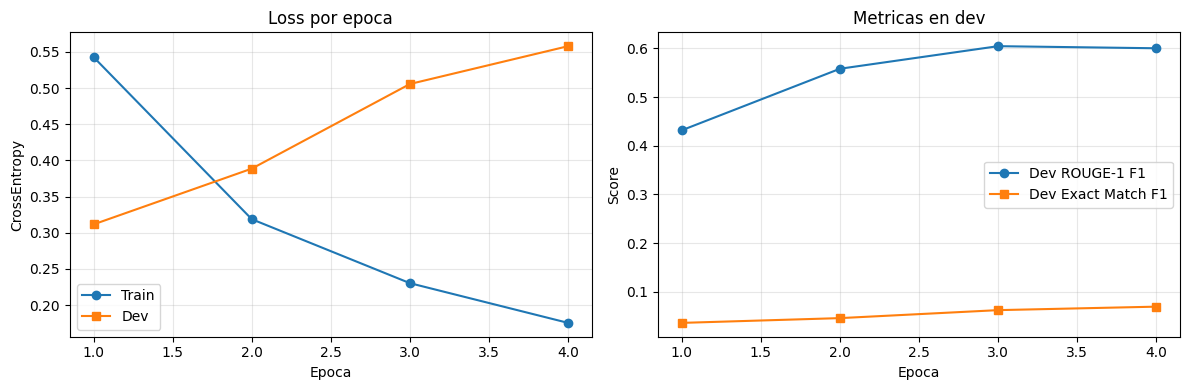

In [14]:
epochs_run = range(1, len(history['train_loss']) + 1)
dev_rouge = [metrics.get('rouge1_f1', 0.0) for metrics in history['dev_metrics']]
dev_exact = [metrics.get('exact_match_f1', 0.0) for metrics in history['dev_metrics']]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs_run, history['train_loss'], marker='o', label='Train')
axes[0].plot(epochs_run, history['dev_loss'], marker='s', label='Dev')
axes[0].set_title('Loss por epoca')
axes[0].set_xlabel('Epoca')
axes[0].set_ylabel('CrossEntropy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_run, dev_rouge, marker='o', label='Dev ROUGE-1 F1')
axes[1].plot(epochs_run, dev_exact, marker='s', label='Dev Exact Match F1')
axes[1].set_title('Metricas en dev')
axes[1].set_xlabel('Epoca')
axes[1].set_ylabel('Score')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'task_c_training_curves.png'), dpi=150)
plt.show()

## 6. Evaluacion del Mejor Modelo en Dev

In [15]:
best_model = load_span_model(BEST_MODEL_DIR, device=DEVICE).float()
best_dev_loss, best_dev_metrics, best_dev_predictions = evaluate_model(
    best_model, dev_dataset, dev_loader, dev_records, DEVICE, class_weights
)

print(f'Dev loss: {best_dev_loss:.4f}')
print(format_metrics(best_dev_metrics))

Loading weights: 100%|██████████| 200/200 [00:00<00:00, 9137.92it/s]


Dev loss: 0.5056
rouge1_f1=0.6047 | exact_match_precision=0.0433 | exact_match_recall=0.1107 | exact_match_f1=0.0623


In [16]:
sample_rows = []
for record in dev_records[:10]:
    row_id = record.get('row_id')
    gold_spans = ' ||| '.join(span.get('span', '') for span in (record.get('span_annotations') or []))
    pred_spans = ' ||| '.join(candidate.text for candidate in best_dev_predictions.get(row_id, []))
    sample_rows.append({
        'row_id': row_id,
        'primary_label': record.get('primary_label'),
        'gold_spans': gold_spans,
        'pred_spans': pred_spans,
        'source_text': build_source_text(record)[:220],
    })

display(pd.DataFrame(sample_rows))

,row_id,primary_label,gold_spans,pred_spans,source_text
0,7555,General Hope,sigo esperando que algún día comprendan que es...,A ||| sigo esperando que algún día comprendan ...,Mi hermano no entiende por qué estudio tanto\n...
1,1522,Unrealistic Hope,"once I lose 200 pounds, become a millionaire, ...","I just KNOW that ||| once I lose 200 pounds, b...",My Ex Will Definitely Come Back Once They See ...
2,4278,Unrealistic Hope,"once we move into this home, all my stress and...",I truly believe that ||| once we move into thi...,Housing Dream Update: Found Perfect Home and F...
3,7155,Not Hope,,,Está mal pensar que es de mal gusto exigir reg...
4,6539,Unrealistic Hope,"si mi jefe realmente me amara como persona, ve...",tengo la sensación de que ||| si mi jefe realm...,¿Cómo puedo conseguir que mi jefe me ame tanto...
5,8916,Hopelessness,,i ||| hopefully ||| i wont be dead before i re...,i wanna die\nim 15 and basically everyone in m...
6,7256,Sarcastic Hope,claro que esta vez será diferente,"Pero ||| claro que esta vez será diferente, po...","Claro, seguro que esta vez será diferente\nAhí..."
7,8754,Not Hope,,,¿Se entiende mi fragmento?\nContexto: Mis pers...
8,7070,Unrealistic Hope,I hope we pull off the impossible and win it a...,"But somehow, against all logic and professiona...",My team's washed-up roster will somehow win th...
9,4040,Realistic Hope,me gustaría que leyeran los primeros capítulos...,"Quiero saber su opinión ||| espero estén bien,...","Quiero saber su opinión\nHola, espero estén bi..."


## 7. Inferencia y Generacion de Submission

In [17]:
test_logits = collect_logits(best_model, test_loader, DEVICE)
test_predictions = aggregate_predictions(test_dataset, test_logits)

primary_label_mapping = load_primary_labels(PRIMARY_LABELS_PATH) if PRIMARY_LABELS_PATH else None
submission_records = predictions_to_submission(
    test_records, test_predictions, primary_label_mapping=primary_label_mapping
)

submission_path = os.path.join(OUTPUT_DIR, SUBMISSION_NAME)
save_json(submission_records, submission_path)
print(f'Submission guardada en: {submission_path}')
display(pd.DataFrame(submission_records).head(10))

Submission guardada en: ./outputs/task_c_spans_notebook/submission_task_c_notebook.json


,row_id,span_annotations
0,17,"[{'span': 'Sí, claro,'}, {'span': 'seguro que ..."
1,3512,[]
2,4863,"[{'span': 'Quiero'}, {'span': 'conectar ambas ..."
3,6917,"[{'span': 'tal'}, {'span': 'si realmente podrí..."
4,8586,[{'span': 'I'm sure things will magically get ...
5,4432,"[{'span': '¿Creen que'}, {'span': 'si logro id..."
6,3328,[{'span': 'Perhaps the next election will fina...
7,597,"[{'span': 'I want to'}, {'span': 'do everythin..."
8,8312,[{'span': 'I'}]
9,4707,[]


In [18]:
experiment_config = {
    'model_name': MODEL_NAME,
    'max_length': MAX_LENGTH,
    'stride': STRIDE,
    'batch_size': BATCH_SIZE,
    'epochs': NUM_EPOCHS,
    'learning_rate': LR,
    'weight_decay': WEIGHT_DECAY,
    'warmup_ratio': WARMUP_RATIO,
    'seed': SEED,
    'best_dev_loss': best_dev_loss,
    'best_dev_metrics': best_dev_metrics,
    'train_examples': len(train_records),
    'dev_examples': len(dev_records),
    'test_examples': len(test_records),
}

config_path = os.path.join(OUTPUT_DIR, 'experiment_config.json')
save_json(experiment_config, config_path)
print(f'Configuracion guardada en: {config_path}')

Configuracion guardada en: ./outputs/task_c_spans_notebook/experiment_config.json
